In [ ]:
import tensorflow as tf
print(tf.__version__)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D
from tensorflow.keras.models import Model

In [3]:
# Carregamento dos dados
cifar10 = tf.keras.datasets.cifar10
# Separa os dados de treino e teste
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Normaliza os dados de treino e teste
x_train, x_test =  x_train / 255.0, x_test / 255.0
# Transforma os dados de classificacao em um vetor unidimensional, as classes
y_train, y_test = y_train.flatten(), y_test.flatten()
# Mostra
print('x_train.shape: ', x_train.shape)
print('y_train.shape: ', y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3370s 20us/step
x_train.shape:  (50000, 32, 32, 3)
y_train.shape:  (50000,)


In [4]:
# Mostra a quantidade de classes
K = len(set(y_train))
print('number of classes: ', K)

number of classes:  10


In [5]:
# COnstrução do Modelo
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [6]:
# Vai compilar e treinar o modelo costruído acima
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 33ms/step - accuracy: 0.4194 - loss: 1.5863 - val_accuracy: 0.5328 - val_loss: 1.3015
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 28ms/step - accuracy: 0.5377 - loss: 1.2799 - val_accuracy: 0.5856 - val_loss: 1.1390
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.5863 - loss: 1.1514 - val_accuracy: 0.6226 - val_loss: 1.0485
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6204 - loss: 1.0671 - val_accuracy: 0.6551 - val_loss: 0.9760
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6455 - loss: 0.9931 - val_accuracy: 0.6670 - val_loss: 0.9384
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6692 - loss: 0.9301 - val_accuracy: 0.6809 - val_loss: 0.9046
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6846 - loss: 0.8842 - val_accuracy: 0.6901 - val_loss: 0.8849
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7038 -

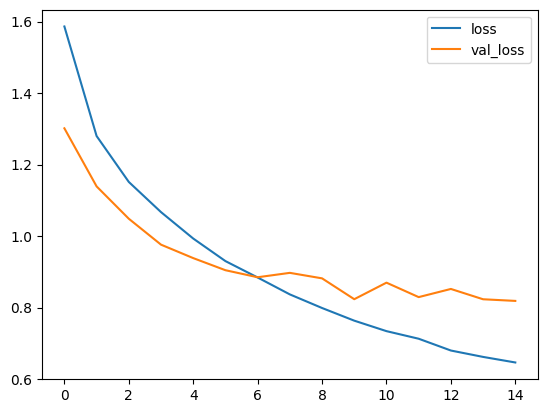

In [10]:
# Grafico de perda por iteracoes
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

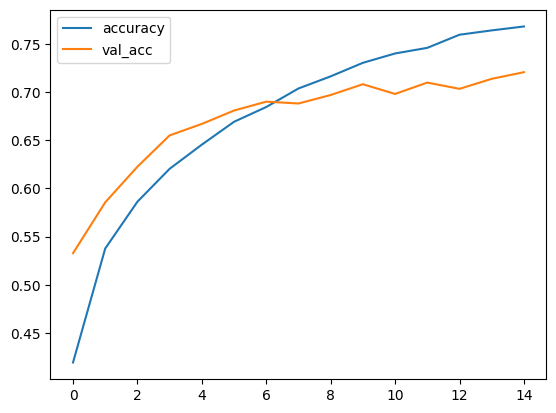

In [11]:
# Grafico da acuracia por iteracoes
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion matrix, without normalization
[[748  26  48  28  26   6  12  15  63  28]
 [ 12 871   5   7   5   5  14   3  18  60]
 [ 51   5 574  58 131  73  62  26  13   7]
 [ 20   8  45 491 105 185  82  46  11   7]
 [ 25   2  40  48 724  42  43  64   4   8]
 [  8   2  29 158  74 621  31  66   3   8]
 [  3   5  19  44  61  28 830   4   5   1]
 [ 13   1  24  43  72  40  13 775   3  16]
 [ 47  42  15  16  10  12  14   5 813  26]
 [ 33 118   8  23   4   6  11  20  17 760]]


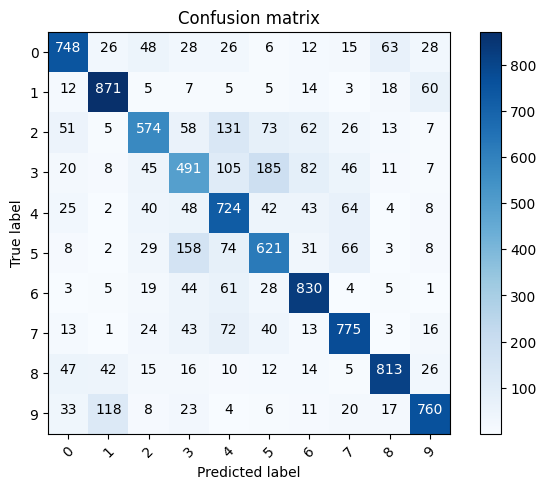

In [14]:
# Controi a matriz de confusao
from sklearn.metrics import confusion_matrix
import itertools

# funcao para plotar a matriz
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    '''
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting 'normalize=True'.
    '''
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalize confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    
    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [15]:
# label mapping
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

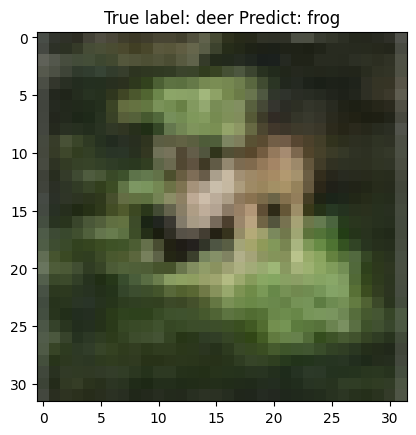

In [32]:
# show some misclassified examples
# TODO: add label names
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predict: %s" % (labels[y_test[i]], labels[p_test[i]]));